# 01 · Explore the data

What you are actually modelling: expeds, features, missing values, and the target family.
Read-only, no training, no submissions. About five minutes.

The Himalayas dataset is **tabular and fully encoded**, instrument ids, feature names and
target definitions are anonymised, so you can model it without financial domain knowledge or
bias. Every row is **one instrument on one `exped`** (a single trading day).

Coming from [`00_setup_and_connect.ipynb`](00_setup_and_connect.ipynb); next is
[`02_train_and_submit.ipynb`](02_train_and_submit.ipynb).

In [12]:
# Install only what is missing. Re-running this cell on a machine that already has
# the SDK should not be a network round-trip that tries to upgrade it.
try:
    import everestapi, pandas, pyarrow, numpy, matplotlib  # noqa: F401
    assert tuple(map(int, everestapi.__version__.split(".")[:3])) >= (0, 3, 32)
except (ImportError, AssertionError, ValueError):
    %pip install --quiet "everestapi>=0.3.32" pandas pyarrow numpy matplotlib

In [13]:
import os
from everestapi import EverestAPI

# Read every credential from the environment, so nothing secret is written into the notebook.
base_url = os.environ.get("EIQ_BASE_URL", "https://app.everesteer.ai")
api_key = os.environ.get("EIQ_API_KEY") or os.environ.get("EVEREST_API_KEY")

# Fail fast with a clear message instead of a cryptic 401/403 deeper in the notebook.
if not api_key:
    raise RuntimeError("Set EIQ_API_KEY (onboarding -> Copy setup command).")

# Only the gated STAGING mirror needs a Cloudflare Access service token; the public
# site does not. The SDK picks the CF_ACCESS_* env vars up automatically when set.
if "staging" in base_url and not (
    os.environ.get("CF_ACCESS_CLIENT_ID") and os.environ.get("CF_ACCESS_CLIENT_SECRET")
):
    raise RuntimeError(
        "Staging is behind Cloudflare Access - set CF_ACCESS_CLIENT_ID / "
        "CF_ACCESS_CLIENT_SECRET, or point EIQ_BASE_URL at the public site."
    )

client = EverestAPI(api_key=api_key, base_url=base_url)
# Only `status` is meaningful here. The health probe is a constant-cost liveness
# check, so its `db` and `dataset` fields are always null by design.
print("connection:", client.health().get("status"))  # -> connection: ok

connection: ok


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# One small palette across every plot in these notebooks, so charts read as one system.
NAVY, TEAL, CORAL, GREY = "#09142F", "#007B63", "#EC9A5F", "#9AA3B2"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GREY, "axes.grid": True, "grid.color": "#E6E9EF",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
})

## The splits

`download_dataset` writes a parquet and returns its path; the version resolves automatically.

| split | targets | what it's for |
|---|---|---|
| `train` | **labeled** | the largest split. Fit on this, and carve your own holdout from it |
| `validation` | blank | the display-only practice board, scored server-side |
| `live` | blank | the split the open round serves. **This is what you are ranked on** |

Two consequences before you start:

- **Only `train` can be scored locally.** The other two ship with their targets blanked and are
  scored server-side, so any holdout you measure on has to be carved out of `train` yourself - which is
  what [`02_train_and_submit.ipynb`](02_train_and_submit.ipynb) does. This notebook downloads
  `train` only.
- **`exped` is relabelled on `live`.** `train` and `validation` carry real `exped_NNNN` tokens;
  a sealed round hides the calendar behind synthetic `era_001..era_NNN`, order preserved. The
  numbering restarts every round, so round 1's `era_007` is not round 2's `era_007`. Key any
  cross-round cache or per-era analysis on `(round, era)`, never the label alone.


In [15]:
import pandas as pd

# verbose=True returns the dataset's own schema file, which carries feature_sets
# plus whatever else that panel declares. Every scalar fact (primary_target,
# feature_encoding, ...) is on the COMPACT response, so take membership from one
# call and the graded column from the other.
schema = client.get_dataset_schema()
schema_verbose = client.get_dataset_schema(verbose=True)
feature_sets = schema_verbose["feature_sets"]
target_cols = list(schema["targets"])
# The graded column, straight from the schema - it differs between datasets and
# is NOT necessarily the first entry in `targets`.
PRIMARY_TARGET = schema["primary_target"]

# download_dataset writes a parquet locally and returns its path; the version auto-resolves.
# `train` is the labeled split and the largest - everything below is built from it.
train = pd.read_parquet(client.download_dataset(universe="futures", split="train"))

EXPED = "exped"   # each exped = one trading day (an "expedition")

# Work with the SMALLEST published feature set (fewer features = faster, less
# memory); scale up later for more signal. Which sets exist is a dataset fact -
# some publish small/medium/all tiers, some publish a single set.
FEATURE_SET_NAME = min(feature_sets, key=lambda n: len(feature_sets[n]))
feature_set = feature_sets[FEATURE_SET_NAME]

def exped_num(e):
    # Expeds are ordered strings like "exped_8978"; pull the integer so we can order them in time.
    return int(str(e).split("_")[-1])

# Downsample to every 4th exped purely for speed in this walkthrough; use all of it for real models.
keep = sorted(train[EXPED].unique(), key=exped_num)[::4]
train = train[train[EXPED].isin(keep)]

print(f"train {train.shape}")
print(f"features used: {len(feature_set)} from the {FEATURE_SET_NAME!r} set")

train (117077, 195)
features used: 178 from the 'all' set


## The shape of the table

Columns fall into a few groups:

- **`id`** (e.g. `eiq_504084dfb312a97e`), the instrument. It is the parquet index, not a column
- **`exped`**, the trading day; all rows sharing an exped are one snapshot of the market
- **features** (`feature_*`), bin-coded attributes of each instrument
- **targets** (`target_*`). The forward returns you predict

Anything else is bookkeeping - `data_type`, for instance, records which split a row came from.
The cell below prints whichever of those columns this dataset ships.


In [16]:
meta_cols = [c for c in ["exped", "data_type", "climb_difficulty"] if c in train.columns]
all_feature_cols = [c for c in train.columns if c.startswith("feature_")]

print(f"{train.shape[0]:,} rows x {train.shape[1]:,} columns")
print(f"  expeds:   {train[EXPED].nunique():>5}  (each = one trading day)")
print(f"  features: {len(all_feature_cols):>5}  (using {len(feature_set)} from {FEATURE_SET_NAME!r})")
print(f"  targets:  {len(target_cols):>5}")
print(f"  metadata: id (index) + {meta_cols}")

train[[EXPED] + feature_set[:4] + [PRIMARY_TARGET]].head()

117,077 rows x 195 columns
  expeds:    1631  (each = one trading day)
  features:   178  (using 178 from 'all')
  targets:     15
  metadata: id (index) + ['exped', 'data_type']


,exped,feature_Adfel,feature_Aferni,feature_Afourgagh,feature_Agadir,target_everest
id,,,,,,
1a5165855490f41a,exped_0003,-1,-1,-1,-1,0.50
b18e66590dfa893a,exped_0003,-1,-1,-1,-1,0.25
d69946412fbeab45,exped_0003,-1,-1,-1,-1,0.75
ab4cef6f599ea7de,exped_0003,-1,-1,-1,-1,0.50
968cc6b7473faa0d,exped_0003,-1,-1,-1,-1,0.50


## Expeds

Each `exped` is one trading day, and the rows within it are the investable universe that day.
Scoring is **per exped**, so it helps to treat an exped as a single example rather than
thinking in rows.

The universe drifts over time, so the row count per exped is not constant:

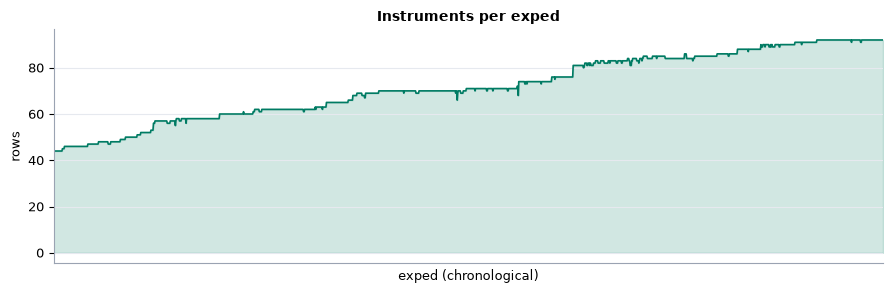

44 to 92 instruments per exped (median 70)


In [17]:
# Order by exped NUMBER, not the default lexicographic string sort, so the x-axis
# runs in true time order.
counts = train.groupby(EXPED).size()
counts = counts.reindex(sorted(counts.index, key=exped_num))

fig, ax = plt.subplots(figsize=(9, 3))
ax.fill_between(range(len(counts)), counts.values, color=TEAL, alpha=0.18)
ax.plot(range(len(counts)), counts.values, color=TEAL, lw=1.2)
ax.set(title="Instruments per exped", xlabel="exped (chronological)", ylabel="rows", xticks=[])
ax.margins(x=0)
plt.tight_layout(); plt.show()

print(f"{counts.min():,} to {counts.max():,} instruments per exped "
      f"(median {int(counts.median()):,})")

## Features, and missing values

Features are quantitative attributes binned into 10 levels. Heavy binning regularises noisy underlying values. Names are encoded
and carry no meaning you can decode.

One value -1.0 encodes missigness. Treat it as NaN or as its own category. Pass it straight through as a number
and the model reads "missing" as one step below bin 0.

The chart below shows how the bins are distributed across the feature set we picked, with the
missing share broken out:


feature names on this panel, verbatim: feature_Adfel, feature_Aferni, feature_Afourgagh, feature_Agadir ...


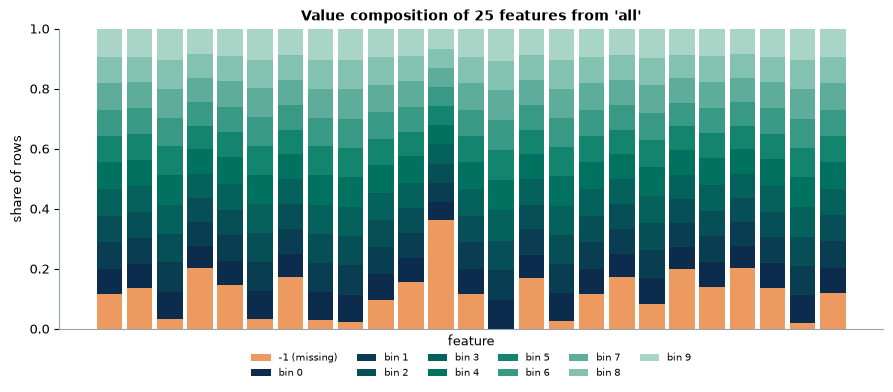

Overall missing share across 'all': 10.8%


In [18]:
sample = feature_set[:25]
print("feature names on this panel, verbatim:", ", ".join(feature_set[:4]), "...")

# How many bins there are is a DATASET fact, not a constant: read the missing
# value from the schema and take the bin values off the data. Hardcoding a
# range here silently drops every bin above it and misstates the shares.
MISSING = (schema.get("feature_encoding") or {}).get("missing")
if MISSING is None:            # absent OR published as null; neither declares one
    MISSING = -1.0
BINS = sorted(v for v in np.unique(train[sample].to_numpy()) if v != MISSING)

shares = []
for f in sample:
    vc = train[f].value_counts(normalize=True)
    shares.append([vc.get(MISSING, 0.0)] + [vc.get(b, 0.0) for b in BINS])
shares = np.array(shares)

fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{MISSING:g} (missing)"] + [f"bin {b:g}" for b in BINS]
# One ramp across however many bins this dataset has.
ramp = LinearSegmentedColormap.from_list("eiq", ["#0B2C4D", TEAL, "#A8D5C6"])
colors = [CORAL] + [ramp(i / max(len(BINS) - 1, 1)) for i in range(len(BINS))]
bottom = np.zeros(len(sample))
for i, (lab, col) in enumerate(zip(labels, colors)):
    ax.bar(range(len(sample)), shares[:, i], bottom=bottom, color=col, label=lab, width=0.85)
    bottom += shares[:, i]

ax.set(title=f"Value composition of {len(sample)} features from {FEATURE_SET_NAME!r}",
       xlabel="feature", ylabel="share of rows", xticks=[], ylim=(0, 1))
ax.grid(False)
ax.legend(ncol=min(len(labels), 6), fontsize=7, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(); plt.show()

missing_overall = (train[feature_set] == MISSING).to_numpy().mean()
print(f"Overall missing share across {FEATURE_SET_NAME!r}: {missing_overall:.1%}")

### Missingness is structured, not random

Sources come online at different times, so missingness arrives in blocks rather than at random:
some features are almost fully missing early in history and dense later. A model handed the
missing value as a number reads those blocks as a real, time-varying signal.


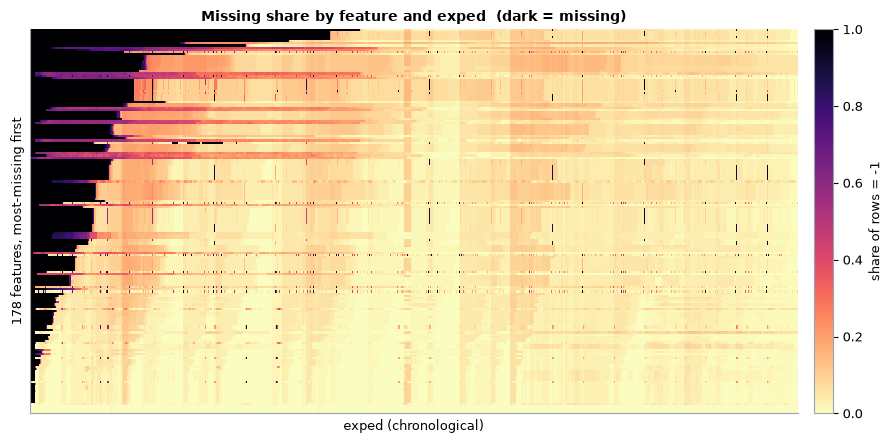

In [19]:
# Missing share per feature per exped, as a heatmap: features (rows) x time (columns).
expeds_sorted = sorted(train[EXPED].unique(), key=exped_num)
miss = (train[feature_set] == MISSING).groupby(train[EXPED]).mean()
miss = miss.reindex(expeds_sorted).T          # features x expeds
miss = miss.loc[miss.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(miss.values, aspect="auto", cmap="magma_r", vmin=0, vmax=1,
               interpolation="nearest")
ax.set(title="Missing share by feature and exped  (dark = missing)",
       xlabel="exped (chronological)", ylabel=f"{len(miss)} features, most-missing first",
       xticks=[], yticks=[])
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label=f"share of rows = {MISSING:g}")
plt.tight_layout(); plt.show()

## Targets

What you predict is a **forward return**. How many targets a dataset publishes, and what
each one means, are dataset facts: the cell above printed the list. Each is a *different
definition* of forward return. **Do not read a horizon off a target's name** - most
datasets do not encode one there.

The **scored target is `PRIMARY_TARGET`** (from the schema), binned into levels the schema
declares in `target_encoding`. Every other target is auxiliary: not scored, but useful to
train on and ensemble. A `NaN` target
means it was uncomputable for that row and is **never imputed**, exclude those rows when
training on that target.

The levels are **bell-shaped, and by construction**: each exped's cross-section is binned to
the same symmetric spread, fattest in the middle and thin at both ends (roughly 5 / 20 / 50 /
20 / 5 percent on this dataset - the chart below is the one on your panel). So the shape is
fixed and carries no information: what you are predicting is an instrument's **position within
its exped**, not a level.


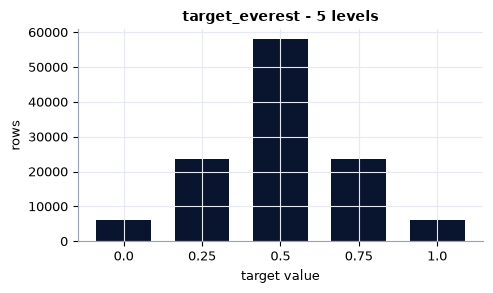

NaN share on the scored target: 0.00%  (never imputed - drop these rows)


In [20]:
fig, ax = plt.subplots(figsize=(5, 3))
dist = train[PRIMARY_TARGET].value_counts().sort_index()
ax.bar([str(i) for i in dist.index], dist.values, color=NAVY, width=0.7)
ax.set(title=f"{PRIMARY_TARGET} - {len(dist)} levels", xlabel="target value", ylabel="rows")
plt.tight_layout(); plt.show()

nan_share = train[PRIMARY_TARGET].isna().mean()
print(f"NaN share on the scored target: {nan_share:.2%}  (never imputed - drop these rows)")

### Which targets are worth ensembling

Targets that correlate strongly with the scored one capture much the same return;
weakly-correlated ones add diversity and make the more interesting ensemble candidates.

**Which is which is a property of the dataset you are on, so read it off the matrix below
rather than carrying numbers over from another event.** Two things to look for: a near-
duplicate of the scored target adds little on its own. Keep one of any such pair rather
than both; and a pair sitting near −1.0 are inverses of one signal, so never include
both raw.

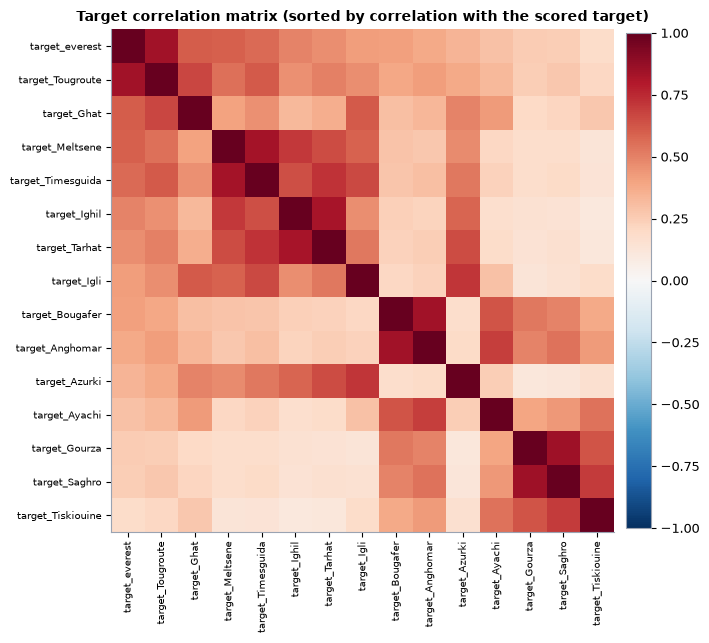

,corr_with_target_everest
target_Tougroute,0.836356
target_Ghat,0.601918
target_Meltsene,0.601270
target_Timesguida,0.565117
target_Ighil,0.492221
target_Tarhat,0.464582
target_Igli,0.417290
target_Bougafer,0.407978
target_Anghomar,0.381798
target_Azurki,0.337785


In [21]:
corr_matrix = train[target_cols].corr()
order = corr_matrix[PRIMARY_TARGET].sort_values(ascending=False).index
corr_matrix = corr_matrix.loc[order, order]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
labels = list(corr_matrix.columns)   # names as the schema gives them, no prefix stripping
ax.set(title="Target correlation matrix (sorted by correlation with the scored target)")
ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels)), labels, fontsize=7)
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout(); plt.show()

corr_matrix[PRIMARY_TARGET].drop(PRIMARY_TARGET).sort_values(ascending=False).to_frame(
    f"corr_with_{PRIMARY_TARGET}")

## What you now know

- One row = one instrument on one exped; **scoring is per exped**.
- Features are bin-coded, and the value meaning *missing* (from the schema's
  `feature_encoding`) is **not a low bin** - it is structured in time, so never feed it in raw.
- You predict the schema's `primary_target`; every other target is ensemble material.

**Next:** [`02_train_and_submit.ipynb`](02_train_and_submit.ipynb). Fit a baseline, measure it on a
held-out tail, and enter a round.